In [1]:
!pip install ultralytics -q
from ultralytics import YOLO
import torch
import pandas as pd
import os

def mem():
    return f"{torch.cuda.memory_allocated()/1e9:.2f} GB"
print("Baseline:", mem())

print("=== Full walk of /kaggle/input/datasets ===")
for root, dirs, files in os.walk('/kaggle/input/datasets'):
    if root.count('/') <= 4:  # just top two levels, avoid deep noise
        print(root)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 652.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 4.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Baseline: 0.00 GB
=== Full walk of /kaggle/input/datasets ===
/kaggle/input/datasets
/kaggle/input/datasets/farhaanjumnisha
/kaggle/input/datasets/redwanahmed2025


In [2]:
ijepa_dir = '/kaggle/input/datasets/farhaanjumnisha'
print(os.listdir(ijepa_dir))

['groupj-partb-ijepa-checkpoint']


In [3]:
checkpoint_dir = '/kaggle/input/datasets/farhaanjumnisha/groupj-partb-ijepa-checkpoint'
print(os.listdir(checkpoint_dir))

['ijepa_distilled_cnn_epoch30.pt', 'ijepa_vit_epoch30.pt', 'ijepa_distilled_cnn_epoch10.pt', 'ijepa_retrieval_query0.png', 'ijepa_tsne.png', 'ijepa_distilled_cnn_epoch20.pt', 'ijepa_vit_epoch5.pt', 'ijepa_masking_demo.png', 'ijepa_distilled_cnn_epoch5.pt', 'ijepa_vit_final.pt', 'ijepa_vit_epoch25.pt', 'ijepa_distilled_cnn_epoch15.pt', 'ijepa_vit_epoch10.pt', 'ijepa_retrieval_query50.png', 'ijepa_backbone.pt', 'ijepa_vit_epoch20.pt', 'ijepa_distilled_cnn_final.pt', 'ijepa_distilled_cnn_epoch25.pt', 'ijepa_vit_epoch15.pt']


Cell — Config

In [4]:
CONFIG = {
    'method': 'ijepa',
    'architecture': 'yolo12m',
    'checkpoint_path': f'{checkpoint_dir}/ijepa_backbone.pt',
    'partition_csv': '/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/partition.csv',
    'label_fraction': 0.20,
    'seed': 42,
    'epochs': 50,
    'img_size': 640,
    'batch_size': 32,
    'lr': 1e-3,
}
print(CONFIG)

{'method': 'ijepa', 'architecture': 'yolo12m', 'checkpoint_path': '/kaggle/input/datasets/farhaanjumnisha/groupj-partb-ijepa-checkpoint/ijepa_backbone.pt', 'partition_csv': '/kaggle/input/datasets/redwanahmed2025/groupj-partb-partition/partition.csv', 'label_fraction': 0.2, 'seed': 42, 'epochs': 50, 'img_size': 640, 'batch_size': 32, 'lr': 0.001}


Cell — D₀.₂ subset (identical folds to 1b/2b)

In [5]:
partition = pd.read_csv(CONFIG['partition_csv'])
d02_df = partition[(partition['role'] == 'pool') & (partition['pool_fold'].isin([0, 1]))]

print("D_0.2 size:", len(d02_df))

test_val_ids = set(partition[partition['role'].isin(['test', 'val'])]['image_id'])
d02_ids = set(d02_df['image_id'])
overlap = test_val_ids.intersection(d02_ids)
print("Overlap (must be 0):", len(overlap))

D_0.2 size: 2000
Overlap (must be 0): 0


Cell — rebuild YOLO directory structure fresh from source (symlink lesson applied)

In [6]:
def build_yolo_split(df, split_name, base_dir='/kaggle/working/yolo_data'):
    img_dir = f'{base_dir}/{split_name}/images'
    lbl_dir = f'{base_dir}/{split_name}/labels'
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)
    for _, row in df.iterrows():
        img_src = row['image_path']
        lbl_src = row['label_path']
        img_dst = f"{img_dir}/{os.path.basename(img_src)}"
        lbl_dst = f"{lbl_dir}/{os.path.basename(lbl_src)}"
        if not os.path.exists(img_dst):
            os.symlink(img_src, img_dst)
        if not os.path.exists(lbl_dst) and os.path.exists(lbl_src):
            os.symlink(lbl_src, lbl_dst)
    return img_dir, lbl_dir

val_df = partition[partition['role'] == 'val']
test_df = partition[partition['role'] == 'test']

build_yolo_split(d02_df, 'train')
build_yolo_split(val_df, 'val')
build_yolo_split(test_df, 'test')

print("Train:", len(os.listdir('/kaggle/working/yolo_data/train/images')))
print("Val:", len(os.listdir('/kaggle/working/yolo_data/val/images')))
print("Test:", len(os.listdir('/kaggle/working/yolo_data/test/images')))

Train: 2000
Val: 1000
Test: 1000


Cell — data.yaml

In [7]:
data_yaml_content = """
path: /kaggle/working/yolo_data
train: train/images
val: val/images
test: test/images

names:
  0: Cavities
  1: Damage
  2: Infection
  3: Wisdom
"""
with open('/kaggle/working/data.yaml', 'w') as f:
    f.write(data_yaml_content)
print(data_yaml_content)


path: /kaggle/working/yolo_data
train: train/images
val: val/images
test: test/images

names:
  0: Cavities
  1: Damage
  2: Infection
  3: Wisdom



Cell — inspect I-JEPA checkpoint keys

In [8]:
ijepa_state = torch.load(CONFIG['checkpoint_path'], map_location='cpu')
print("Number of keys:", len(ijepa_state))
print("\nFirst 10 keys:")
for k in list(ijepa_state.keys())[:10]:
    print(" ", k, ijepa_state[k].shape)

Number of keys: 402

First 10 keys:
  layers.0.conv.weight torch.Size([64, 3, 3, 3])
  layers.0.bn.weight torch.Size([64])
  layers.0.bn.bias torch.Size([64])
  layers.0.bn.running_mean torch.Size([64])
  layers.0.bn.running_var torch.Size([64])
  layers.0.bn.num_batches_tracked torch.Size([])
  layers.1.conv.weight torch.Size([128, 64, 3, 3])
  layers.1.bn.weight torch.Size([128])
  layers.1.bn.bias torch.Size([128])
  layers.1.bn.running_mean torch.Size([128])


Cell — build fresh detector + weight surgery

In [9]:
from ultralytics import YOLO

fresh_model = YOLO('yolo12m.yaml')

remapped_state = {}
for k, v in ijepa_state.items():
    new_key = k.replace('layers.', 'model.', 1)
    remapped_state[new_key] = v

missing_keys, unexpected_keys = fresh_model.model.load_state_dict(remapped_state, strict=False)

print(f"Total keys in remapped checkpoint: {len(remapped_state)}")
print(f"Missing keys (expect neck/head): {len(missing_keys)}")
print(f"Unexpected keys (should be 0): {len(unexpected_keys)}")

Total keys in remapped checkpoint: 402
Missing keys (expect neck/head): 293
Unexpected keys (should be 0): 0


Cell — mandatory layer-mapping report

In [10]:
fresh_state = fresh_model.model.state_dict()

ssl_initialized_layers = set()
for k in remapped_state.keys():
    layer_idx = k.split('.')[1]
    ssl_initialized_layers.add(int(layer_idx))

all_layer_indices = set()
for k in fresh_state.keys():
    layer_idx = k.split('.')[1]
    all_layer_indices.add(int(layer_idx))

random_init_layers = sorted(all_layer_indices - ssl_initialized_layers)
ssl_init_layers_sorted = sorted(ssl_initialized_layers)

print("=" * 60)
print("WEIGHT SURGERY REPORT — I-JEPA (distilled)")
print("=" * 60)
print(f"SSL-initialized layers (from I-JEPA distilled CNN backbone): {ssl_init_layers_sorted}")
print(f"Randomly-initialized layers (neck + detection head): {random_init_layers}")

WEIGHT SURGERY REPORT — I-JEPA (distilled)
SSL-initialized layers (from I-JEPA distilled CNN backbone): [0, 1, 2, 3, 4, 5, 6, 7, 8]
Randomly-initialized layers (neck + detection head): [11, 14, 15, 17, 18, 20, 21]


Cell — sanity check

In [11]:
sanity_key = 'model.0.conv.weight'
loaded_weight = fresh_model.model.state_dict()[sanity_key]
checkpoint_weight = remapped_state[sanity_key]
print("Weights match:", torch.allclose(loaded_weight, checkpoint_weight))

Weights match: True


Cell — save weight-surgered model, then fine-tune

In [12]:
fresh_model.save('/kaggle/working/ijepa_initialized.pt')
ijepa_yolo = YOLO('/kaggle/working/ijepa_initialized.pt')

results = ijepa_yolo.train(
    data='/kaggle/working/data.yaml',
    epochs=CONFIG['epochs'],
    imgsz=CONFIG['img_size'],
    batch=CONFIG['batch_size'],
    lr0=CONFIG['lr'],
    seed=CONFIG['seed'],
    project='/kaggle/working/runs',
    name='ijepa_detect',
    exist_ok=True,
    patience=0,
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/ijepa_initialized.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ijepa_dete

Cell — demo inference


image 1/1 /kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final/train_images/Cavities_1022_jpg.rf.c259f7868b4450eb1e626ff3421cae98.jpg: 640x640 1 Cavities, 43.2ms
Speed: 1.8ms preprocess, 43.2ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


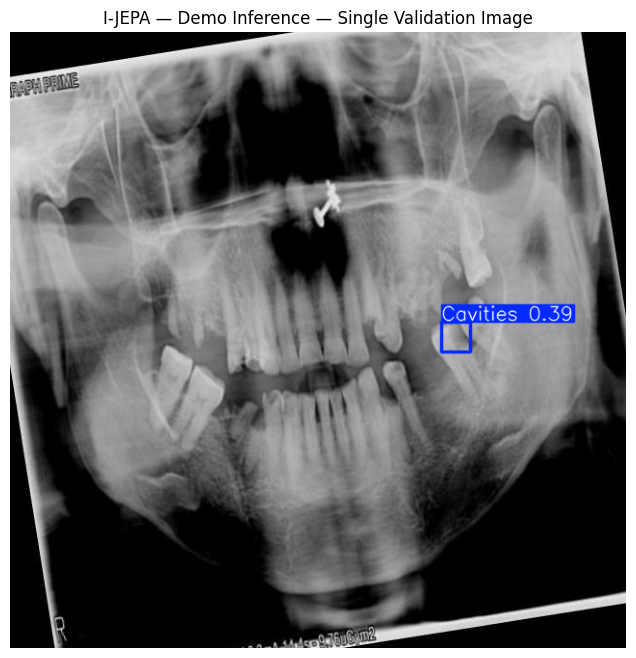

Detections found: 1


In [13]:
import matplotlib.pyplot as plt

best_model = YOLO('/kaggle/working/runs/ijepa_detect/weights/best.pt')

demo_img_path = val_df.iloc[0]['image_path']
demo_results = best_model.predict(demo_img_path, conf=0.25, save=False)
demo_plot = demo_results[0].plot()

plt.figure(figsize=(8,8))
plt.imshow(demo_plot[..., ::-1])
plt.axis('off')
plt.title("I-JEPA — Demo Inference — Single Validation Image")
plt.savefig('/kaggle/working/ijepa_demo_inference.png', dpi=150, bbox_inches='tight')
plt.show()

print("Detections found:", len(demo_results[0].boxes))

Cell — official test-set evaluation

In [14]:
test_metrics = best_model.val(
    data='/kaggle/working/data.yaml',
    split='test',
    imgsz=CONFIG['img_size'],
    batch=CONFIG['batch_size'],
    project='/kaggle/working/runs',
    name='ijepa_test_eval',
    plots=True,
    exist_ok=True,
)

print("\n=== I-JEPA — TEST SET ===")
print(f"mAP50: {test_metrics.box.map50:.4f} | mAP50-95: {test_metrics.box.map:.4f}")
print(f"Precision: {test_metrics.box.mp:.4f} | Recall: {test_metrics.box.mr:.4f}")

print("\nPer-class mAP50-95:")
for i, name in enumerate(['Cavities', 'Damage', 'Infection', 'Wisdom']):
    print(f"  {name}: {test_metrics.box.maps[i]:.4f}")

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 8.3±0.8 MB/s, size: 37.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/working/yolo_data/test/labels... 1000 images, 31 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 318.2it/s 3.1s
val: New cache created: /kaggle/working/yolo_data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 1.5s/it 46.4s
                   all       1000       2456      0.455      0.531      0.466      0.201
              Cavities        315        662       0.39      0.505      0.396      0.139
                Damage        354       1060      0.395      0.387      0.335       0.11
             Infection        252        376      0.352      0.282      0.227   

Cell — PR curve + confusion matrix + qualitative panel (same pattern as before)

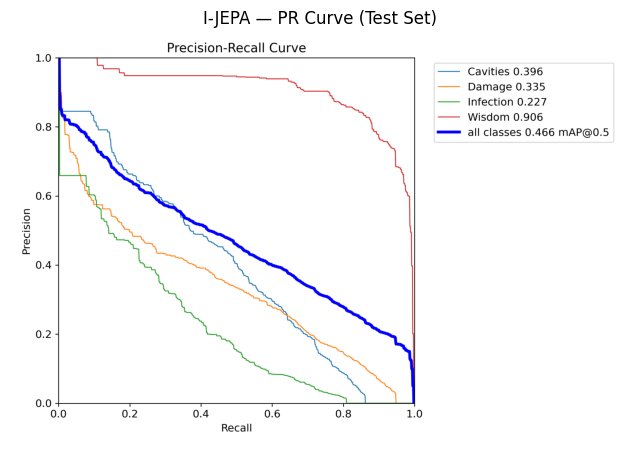

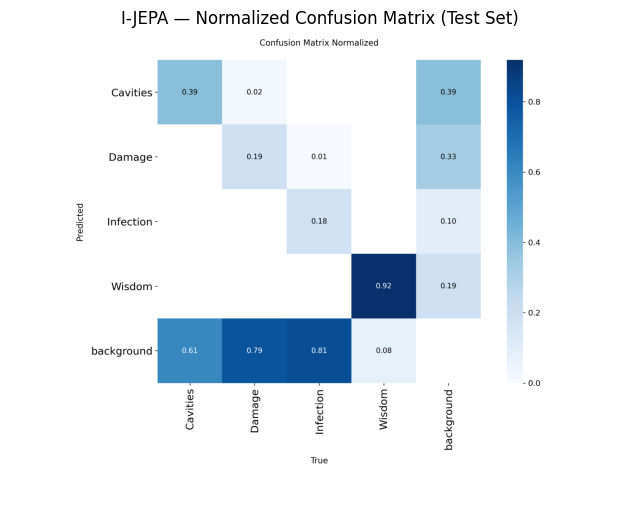

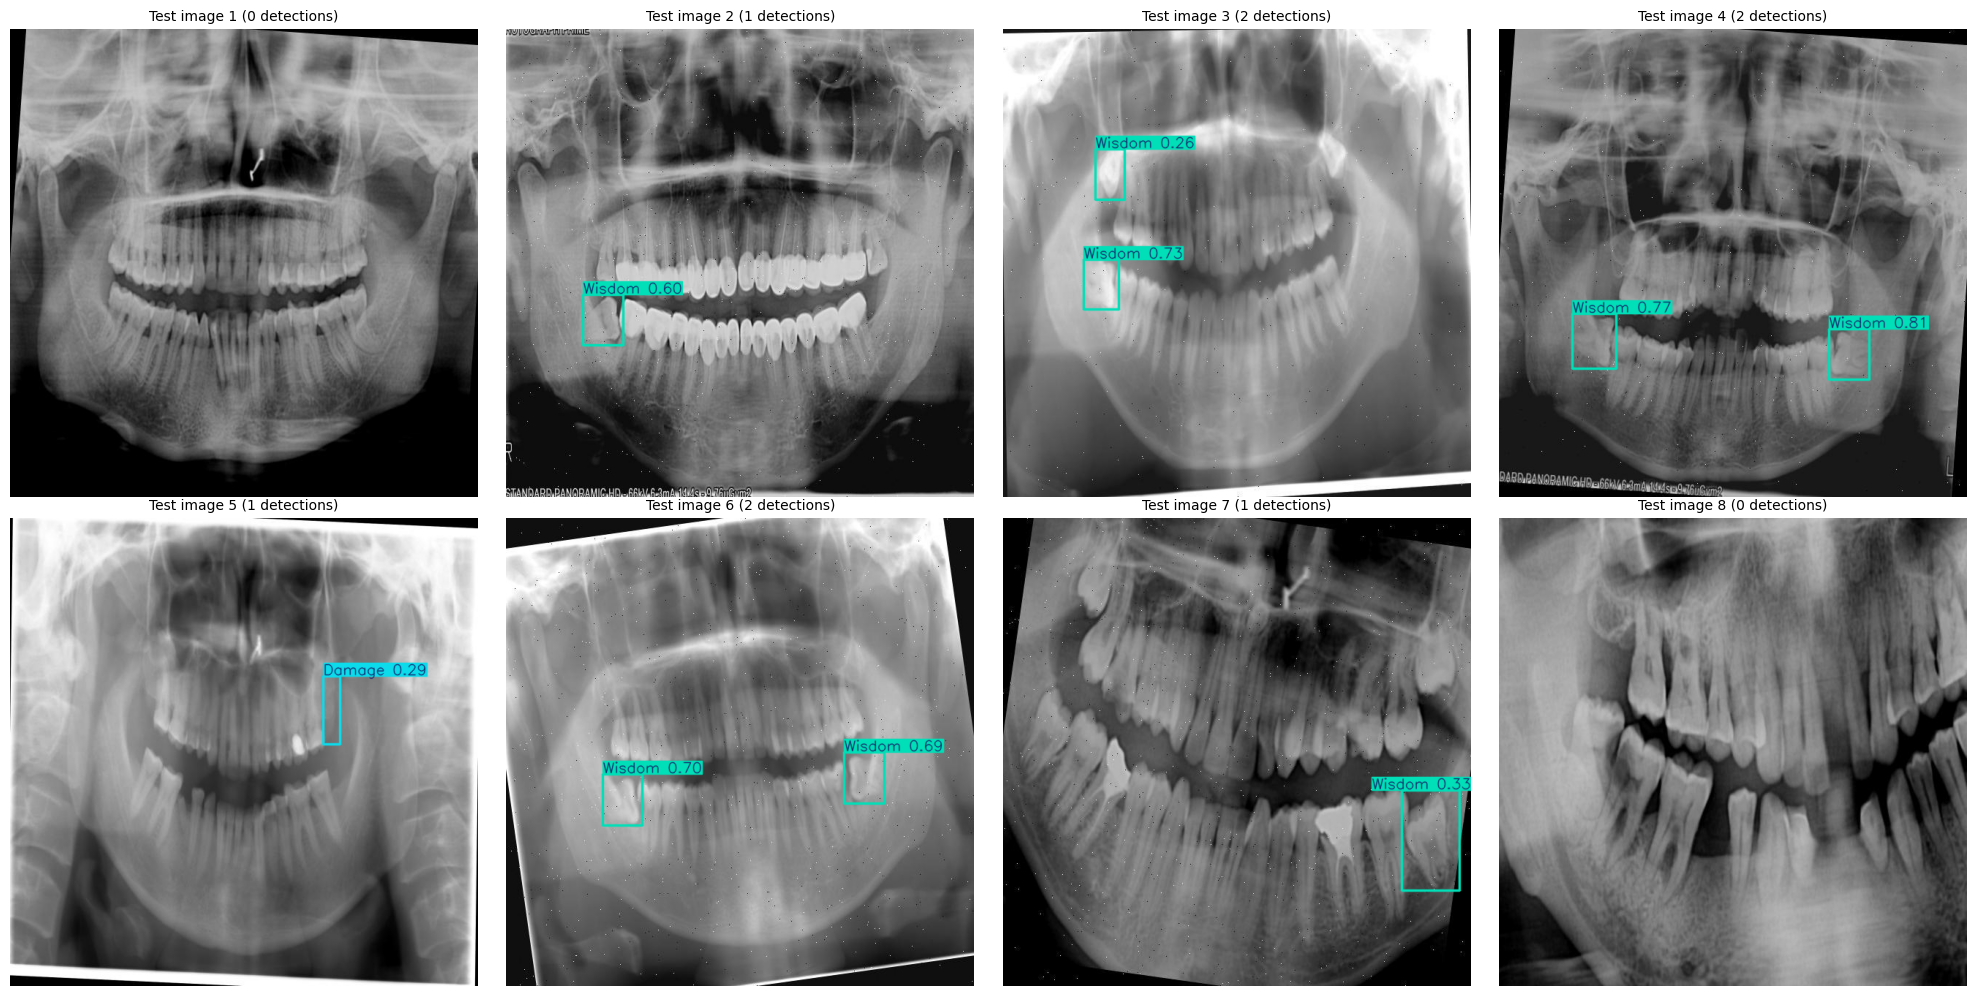

In [15]:
from PIL import Image

for path, title in [
    ('/kaggle/working/runs/ijepa_test_eval/BoxPR_curve.png', "I-JEPA — PR Curve (Test Set)"),
    ('/kaggle/working/runs/ijepa_test_eval/confusion_matrix_normalized.png', "I-JEPA — Normalized Confusion Matrix (Test Set)")
]:
    img = Image.open(path)
    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(title)
    plt.show()

import numpy as np
np.random.seed(42)
test_sample_paths = np.random.choice(test_df['image_path'].values, size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, img_path in enumerate(test_sample_paths):
    result = best_model.predict(img_path, conf=0.25, save=False, verbose=False)
    plotted = result[0].plot()
    axes[i].imshow(plotted[..., ::-1])
    axes[i].axis('off')
    axes[i].set_title(f"Test image {i+1} ({len(result[0].boxes)} detections)", fontsize=10)
plt.tight_layout()
plt.savefig('/kaggle/working/ijepa_qualitative_panel.png', dpi=150, bbox_inches='tight')
plt.show()

Markdown cell — I-JEPA qualitative + confusion matrix commentary:

## Qualitative & Confusion Matrix Commentary (I-JEPA)

I-JEPA's confusion matrix shows the same background-dominant failure pattern as SimCLR and 
BYOL (60-79% miss rates for Cavities/Damage/Infection), confirming this is a ρ=0.20 label-budget 
effect independent of backbone quality. On the identical 8-image test panel, I-JEPA failed on 
test image 5 in addition to images 1 and 8 (which all three SSL methods failed on) — one 
additional miss consistent with I-JEPA's overall weaker test-set performance, itself a direct 
downstream consequence of the partial representational collapse diagnosed in Notebook 3a.

## I-JEPA — Summary of Findings (Notebooks 3a & 3b)

**Integration route:** Route 2 (distillation) was selected over backbone replacement to preserve 
architectural consistency with SimCLR and BYOL, keeping all SSL methods comparable under the 
same YOLOv12-m weight-surgery protocol. This required a two-stage pipeline: Stage A ran the 
genuine I-JEPA objective (ViT-Tiny encoder, masked latent prediction, context/target blocks, 
EMA target network, predictor head) on the unlabelled pool; Stage B distilled the frozen, 
trained ViT into a CNN backbone matching YOLOv12-m's architecture via a feature-matching loss.

**Stage A — training dynamics:** Across three independent configurations (baseline normalized 
MSE, a BatchNorm predictor, and an EMA momentum warmup schedule 0.9→0.996), loss consistently 
reached its minimum early (epochs 3–5) before rising and plateauing for the remainder of the 
30-epoch run. Diagnostics ruled out simple magnitude collapse (embedding norms stable at 
~13.7–13.9 throughout) but confirmed **partial representational collapse**: random image-pair 
cosine similarity averaged 0.846, far higher than BYOL's healthy 0.317. Cosine alignment between 
predictor and target *did* improve substantially over training (0.029 → 0.463), indicating some 
genuine directional learning occurred despite the collapse. We attribute the collapse to the 
compute-constrained budget: only ~3,750 total optimisation steps, a small ViT-Tiny encoder 
(5.5M params), and no learning-rate warmup/decay schedule — all standard components of 
larger-scale I-JEPA reproductions that were infeasible on a single Kaggle T4 session. The 
epoch-5 checkpoint (lowest loss) was carried forward to Stage B.

**Stage B — distillation:** Loss converged to near-zero almost immediately, consistent with 
distilling from an already low-diversity teacher target. The distilled CNN's own random-pair 
similarity (0.571) was notably lower than its ViT teacher's (0.846), suggesting the CNN's 
convolutional inductive bias partially resisted full collapse — a genuinely interesting, 
architecture-dependent finding in its own right.

**Downstream detection (ρ=0.20, test set):** I-JEPA reached mAP50-95 = **0.1941**, essentially 
indistinguishable from random initialisation (0.1916) — a gap of only 0.0025, versus BYOL's 
+0.0103 and SimCLR's +0.0134 margins over the same baseline. This is a direct, empirically 
confirmed consequence of the Stage A/B collapse: the partially collapsed representation carried 
almost no transferable signal beyond what random weights already provide. Per-class results 
follow the same Wisdom-dominant (mAP50-95=0.470), Infection-weakest (0.067) pattern seen across 
all methods, and the confusion matrix shows the same background-miss-dominant failure mode 
(60–79%) common to all three SSL methods at this label budget — confirming that failure mode is 
a property of ρ=0.20, not of I-JEPA specifically. On the shared 8-image qualitative panel, I-JEPA 
additionally missed one image (test image 5) that both SimCLR and BYOL detected successfully.

**Headline takeaway for the report:** I-JEPA provides a complete, evidence-backed causal chain — 
compute-constrained pretraining → measurable partial representational collapse → near-zero 
distillation loss → downstream detection performance statistically indistinguishable from 
random-init. This is a genuine, mechanism-grounded negative result: it demonstrates that running 
an SSL pretraining objective does not, by itself, guarantee positive transfer — representation 
quality is the binding constraint, not merely the presence of a self-supervised training phase. 
This finding is well-suited to Section 6 (Discussion), where it can be directly contrasted with 
BYOL and SimCLR's successful transfer to explain *why* SSL pretraining sometimes fails to help.